# Análisis exploratorio de datos (EDA)

Cargamos nuestro dataset

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/breast-cancer-wisconsin.csv")
df.shape

(569, 33)

Podemos observar que nuestro dataframe cuenta con **569** registros y **32** atributos, todos númericos

In [3]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [4]:
df = df.drop(columns=["id", "Unnamed: 32"])
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [5]:
pd.DataFrame({
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Dtype": df.dtypes
})

,Non-Null Count,Null Count,Dtype
diagnosis,569,0,object
radius_mean,569,0,float64
texture_mean,569,0,float64
perimeter_mean,569,0,float64
area_mean,569,0,float64
smoothness_mean,569,0,float64
compactness_mean,569,0,float64
concavity_mean,569,0,float64
concave points_mean,569,0,float64
symmetry_mean,569,0,float64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## Porcentaje de afectados

Calculamos el porcentaje de personas con y sin diabetes.

Frecuencia relativa * 100 (con 2 decimales)

In [7]:
(df["diagnosis"].value_counts(normalize=True) * 100).round(2) # Porcentaje

diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64

In [8]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

## Cantidad de valores únicos

In [9]:
df.nunique()

diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
dtype: int64

In [10]:
df["diagnosis"].unique()

array(['M', 'B'], dtype=object)

In [11]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
df["diagnosis"].unique()

array([1, 0])

In [12]:
from utils import estandarizar_columnas_no_binarias

df = estandarizar_columnas_no_binarias(df, True)

Columnas estandarizadas: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [13]:
df.describe().round(1)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,...,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0,569.0
mean,0.4,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,...,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0
std,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,0.0,-2.0,-2.2,-2.0,-1.5,-3.1,-1.6,-1.1,-1.3,-2.7,...,-1.7,-2.2,-1.7,-1.2,-2.7,-1.4,-1.3,-1.7,-2.2,-1.6
25%,0.0,-0.7,-0.7,-0.7,-0.7,-0.7,-0.7,-0.7,-0.7,-0.7,...,-0.7,-0.7,-0.7,-0.6,-0.7,-0.7,-0.8,-0.8,-0.6,-0.7
50%,0.0,-0.2,-0.1,-0.2,-0.3,-0.0,-0.2,-0.3,-0.4,-0.1,...,-0.3,-0.0,-0.3,-0.3,-0.0,-0.3,-0.2,-0.2,-0.1,-0.2
75%,1.0,0.5,0.6,0.5,0.4,0.6,0.5,0.5,0.6,0.5,...,0.5,0.7,0.5,0.4,0.6,0.5,0.5,0.7,0.4,0.5
max,1.0,4.0,4.6,4.0,5.2,4.8,4.6,4.2,3.9,4.5,...,4.1,3.9,4.3,5.9,4.0,5.1,4.7,2.7,6.0,6.8


## Correlación de atributos

Calculamos la matriz de correlación, esto lo que hace es medir el grado de asosiación lineal entre cada par de atributos de nuestros datos. Se calcula de la siguiente manera:

$\rho(X, Y) = \frac{Cov(X, Y)}{s_x s_y}$  

Y la covarianza se calcula como:  

$Cov(X, Y) = \frac{1}{n} \sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})$

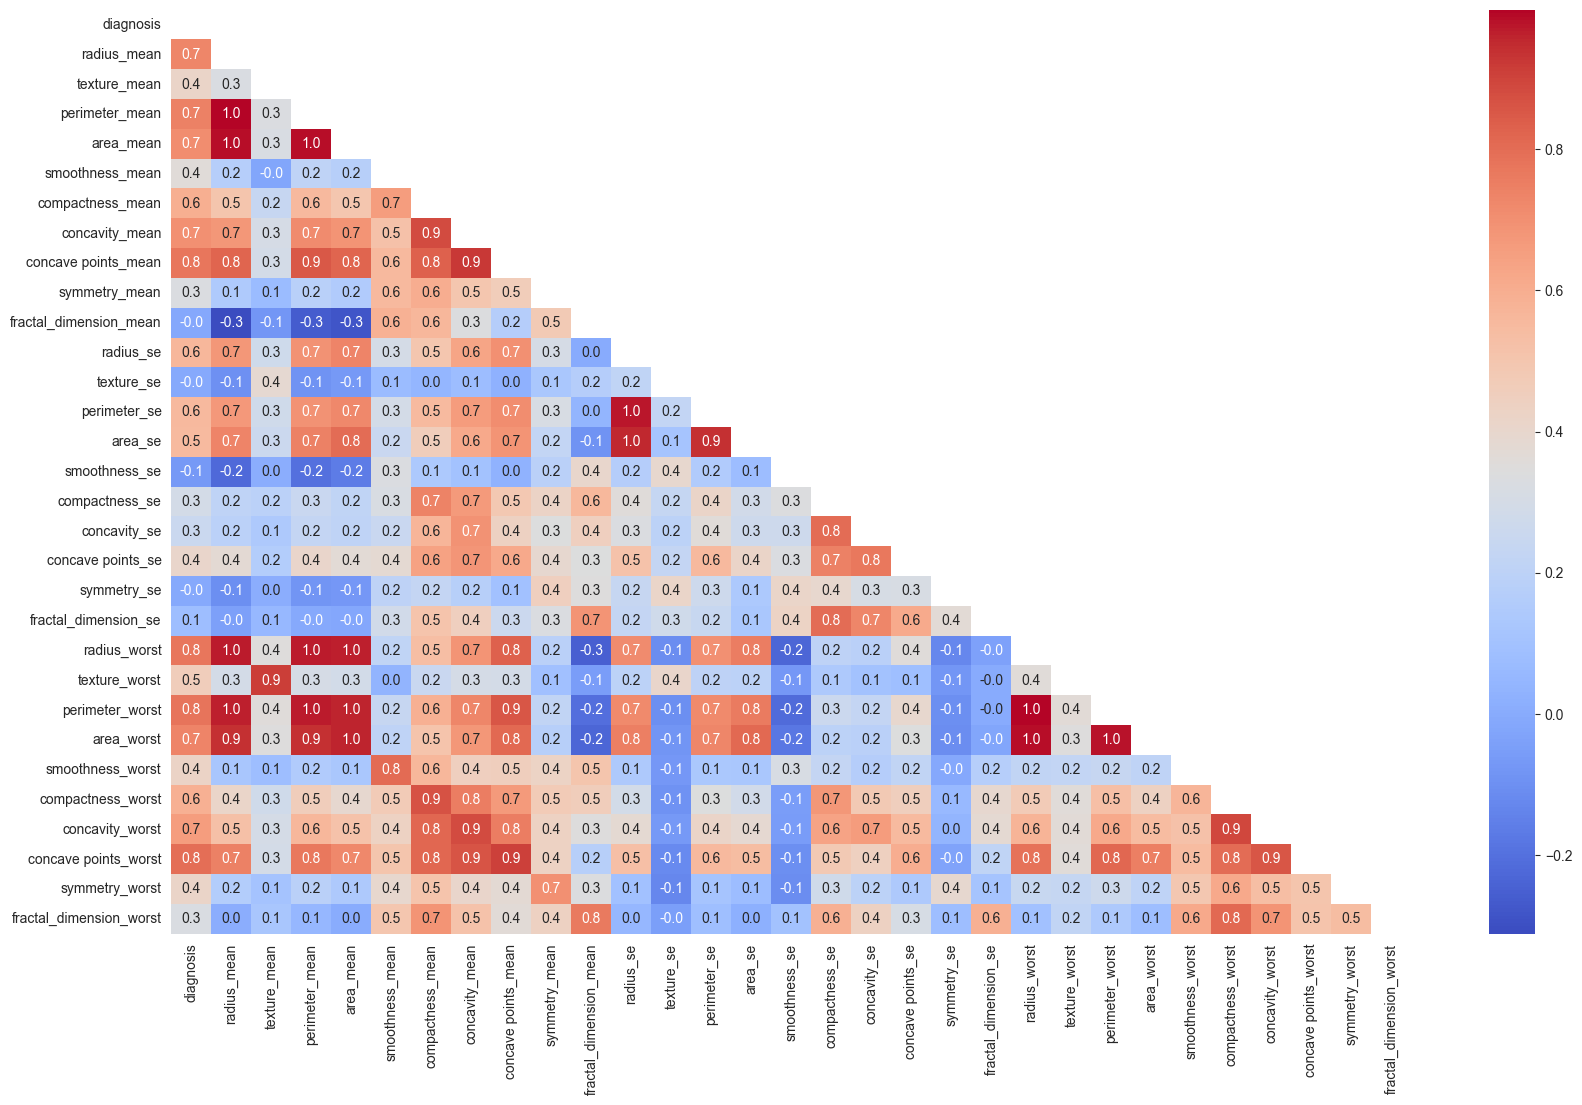

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("white")

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 12))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0, linecolor='white')
plt.show()

## Boxplot

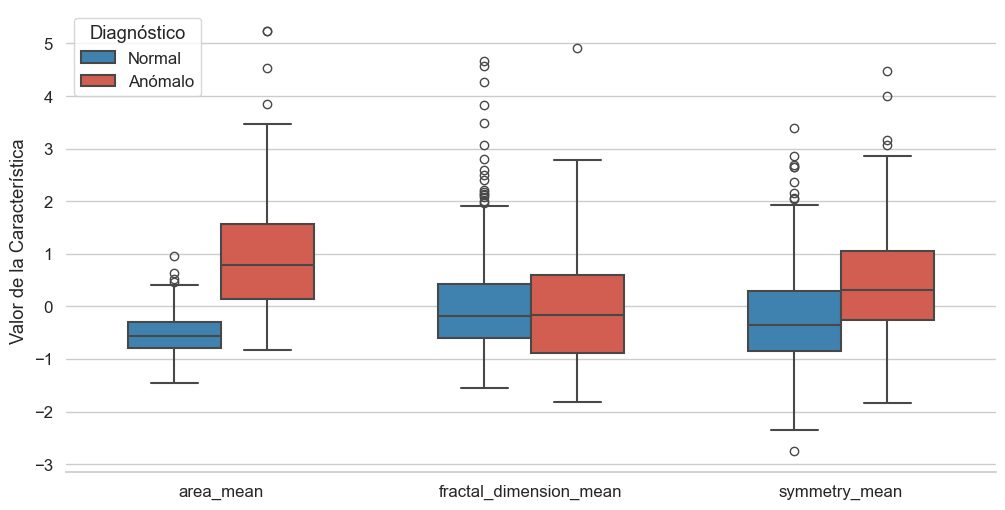

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que 'df' es su DataFrame original
plot_df = df.copy() 

# 1. Mapear la columna de diagnóstico a etiquetas
plot_df['diagnosis'] = plot_df['diagnosis'].map({0: 'Normal', 1: 'Anómalo'})

# 2. Definir las tres columnas que se van a graficar
columnas_a_graficar = [
    'area_mean', 
    'fractal_dimension_mean', 
    'symmetry_mean' # Usando 'symmetry_mean' que es el nombre correcto del atributo
]

# 3. Reestructurar el DataFrame (Melting)
# Convertimos las columnas de características a filas, manteniendo 'diagnosis' como identificador
df_melted = pd.melt(
    plot_df,
    id_vars=['diagnosis'],
    value_vars=columnas_a_graficar,
    var_name='Atributo',
    value_name='Valor'
)

# --- Configuración y Generación del Gráfico Único ---
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
colores = {'Normal': '#2E86C1', 'Anómalo': '#E74C3C'}
orden_deseado = ['Normal', 'Anómalo']

plt.figure(figsize=(12, 6)) 

# Usamos 'Atributo' en el eje X y 'diagnosis' para el color (hue)
sns.boxplot(
    data=df_melted, 
    x='Atributo', 
    y='Valor', 
    hue='diagnosis', 
    palette=colores, 
    hue_order=orden_deseado,
    linewidth=1.5, 
    width=0.6
)

plt.ylabel('Valor de la Característica')
plt.xlabel('') # Dejamos la etiqueta vacía ya que 'Atributo' será el nombre de la columna
#plt.title('Distribución de Características Clave por Diagnóstico', fontweight='bold', pad=10)
plt.legend(title='Diagnóstico')
sns.despine(left=True, top=True)

plt.show()

Boxplot de atributo: radius_mean


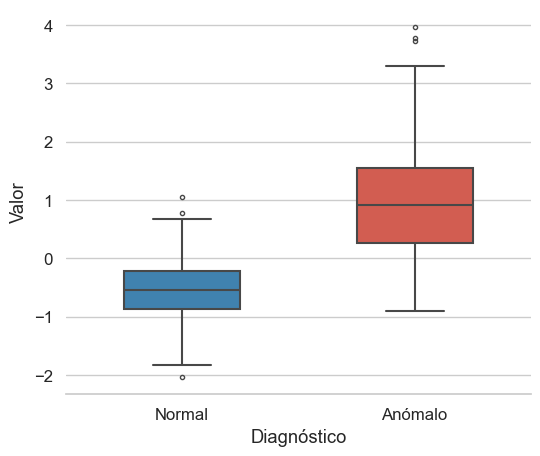

Boxplot de atributo: texture_mean


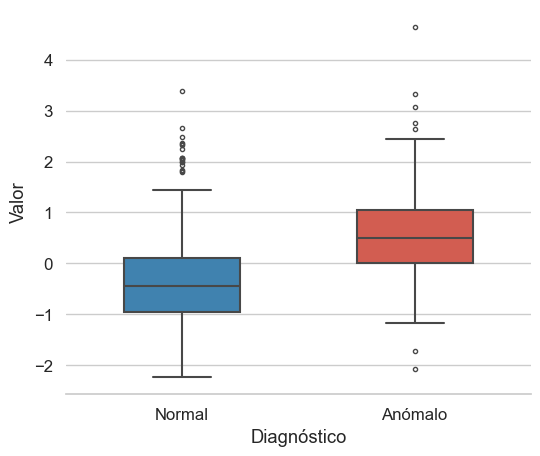

Boxplot de atributo: perimeter_mean


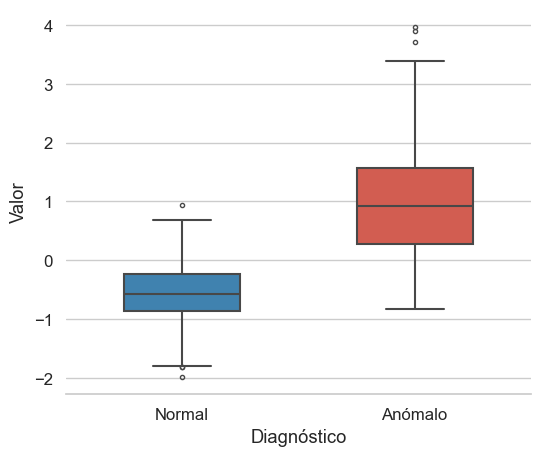

Boxplot de atributo: area_mean


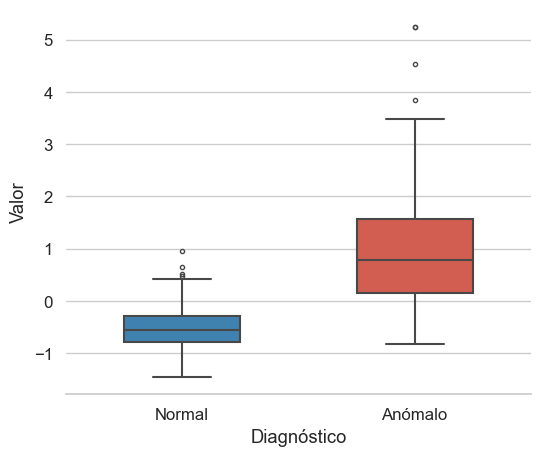

Boxplot de atributo: smoothness_mean


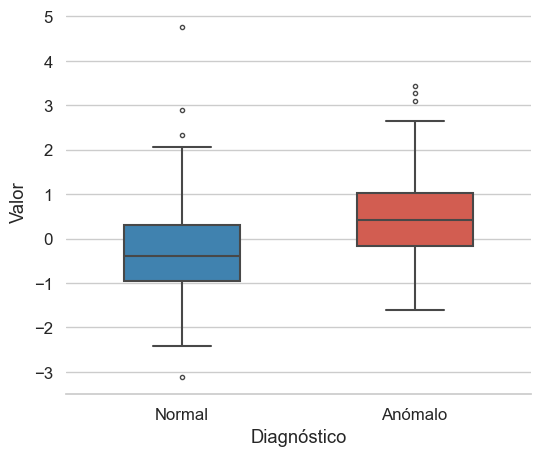

Boxplot de atributo: compactness_mean


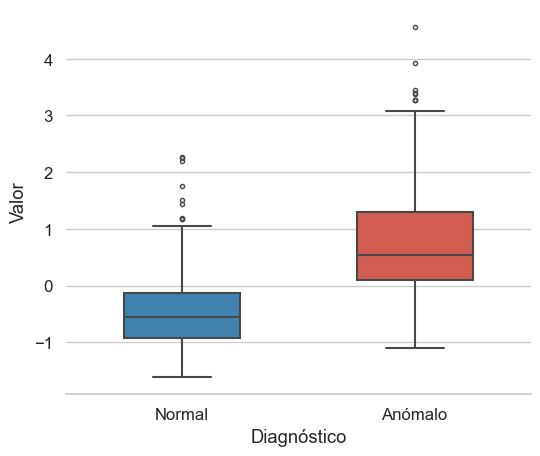

Boxplot de atributo: concavity_mean


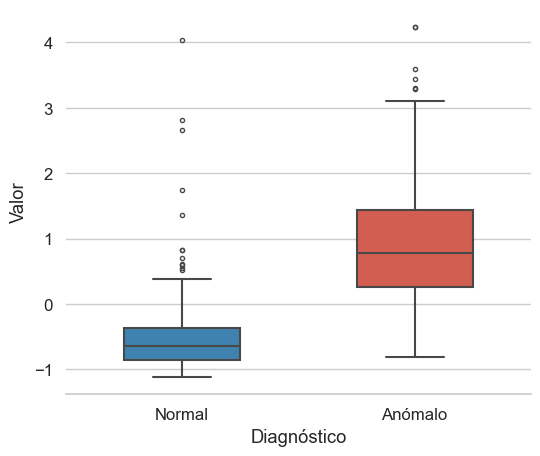

Boxplot de atributo: concave points_mean


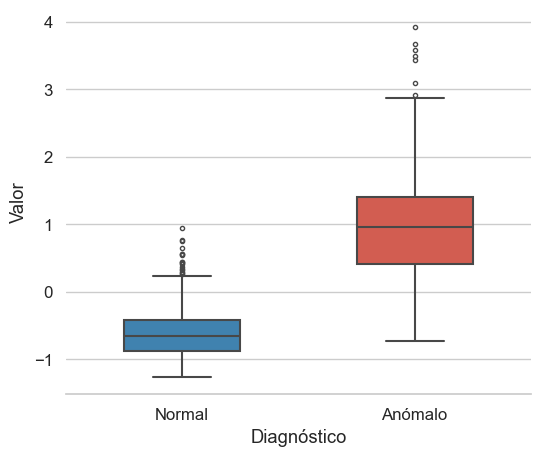

Boxplot de atributo: symmetry_mean


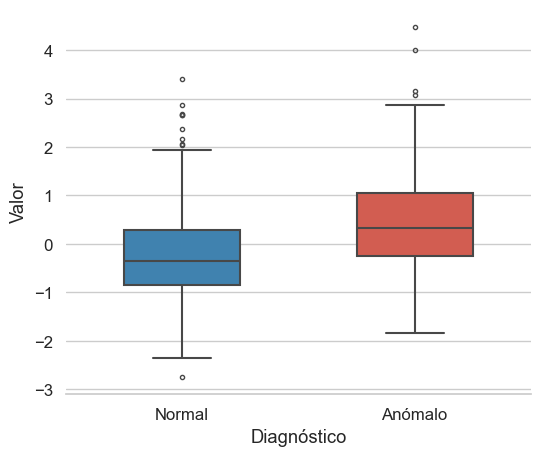

Boxplot de atributo: fractal_dimension_mean


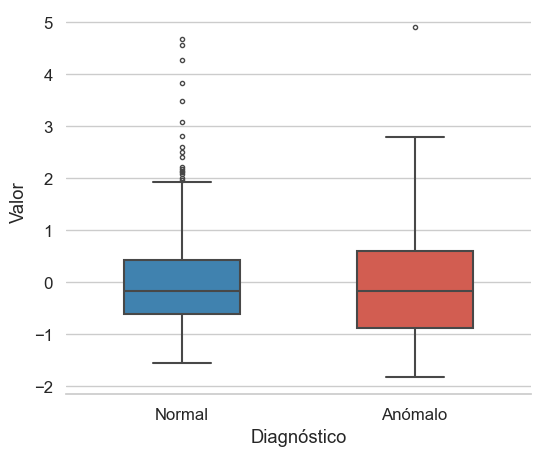

Boxplot de atributo: radius_se


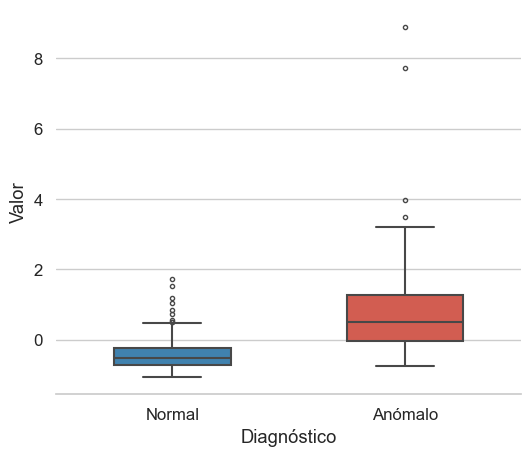

Boxplot de atributo: texture_se


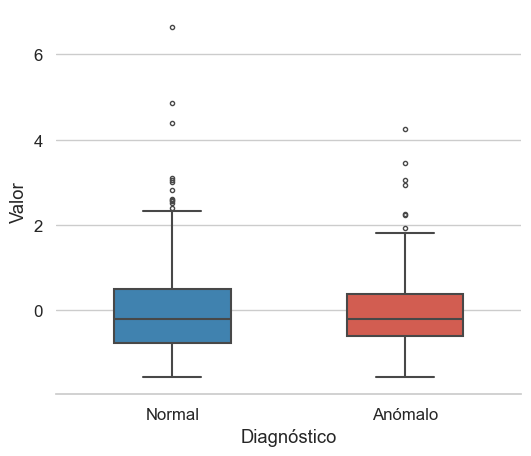

Boxplot de atributo: perimeter_se


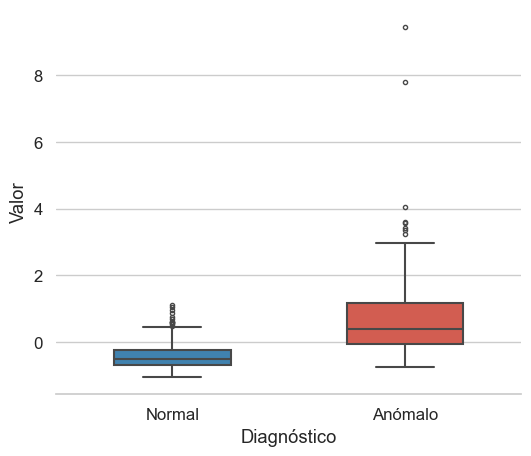

Boxplot de atributo: area_se


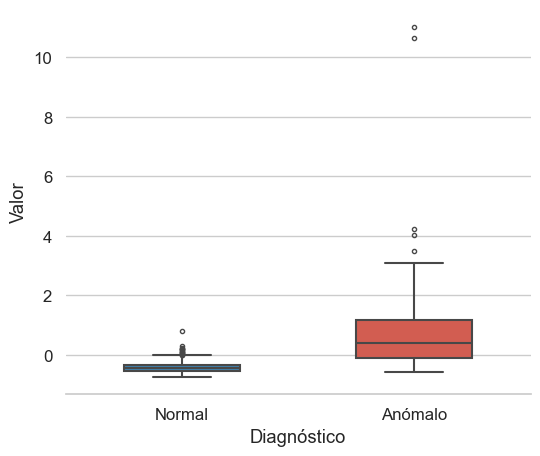

Boxplot de atributo: smoothness_se


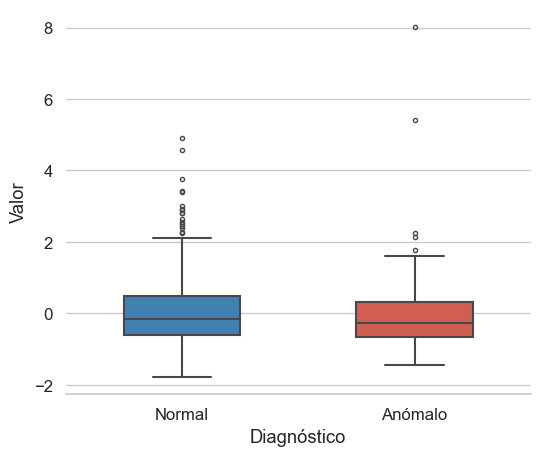

Boxplot de atributo: compactness_se


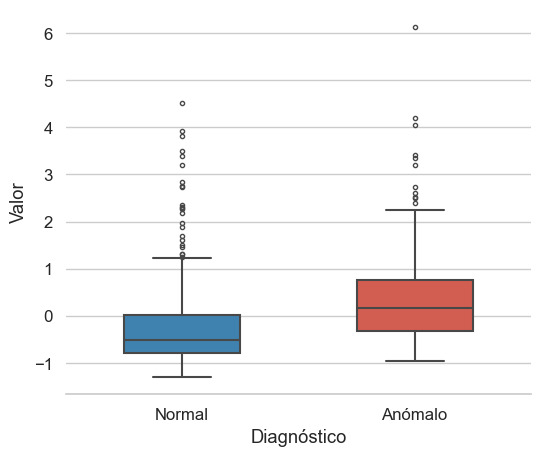

Boxplot de atributo: concavity_se


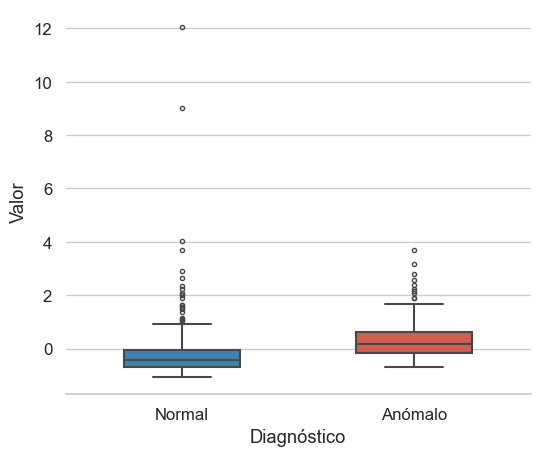

Boxplot de atributo: concave points_se


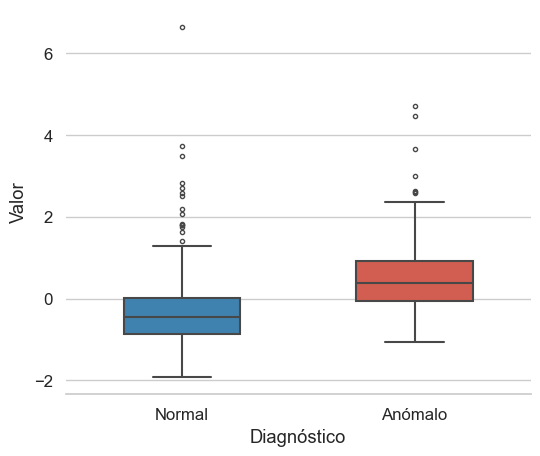

Boxplot de atributo: symmetry_se


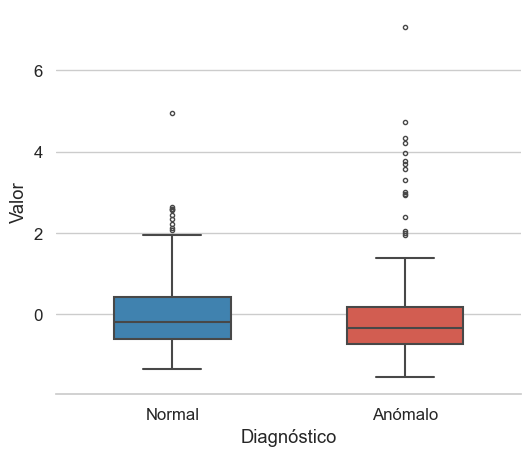

Boxplot de atributo: fractal_dimension_se


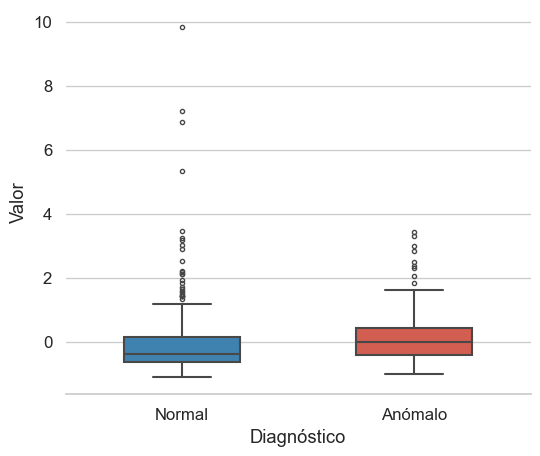

Boxplot de atributo: radius_worst


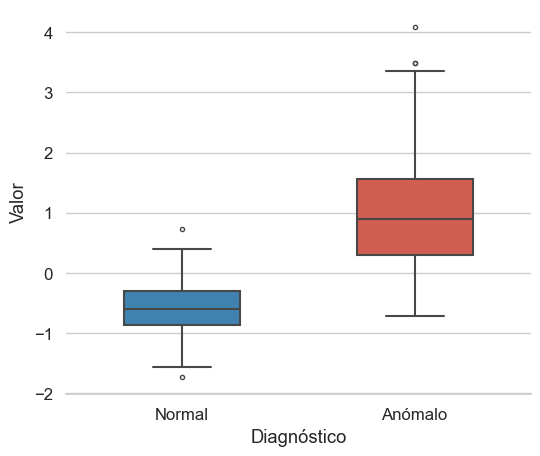

Boxplot de atributo: texture_worst


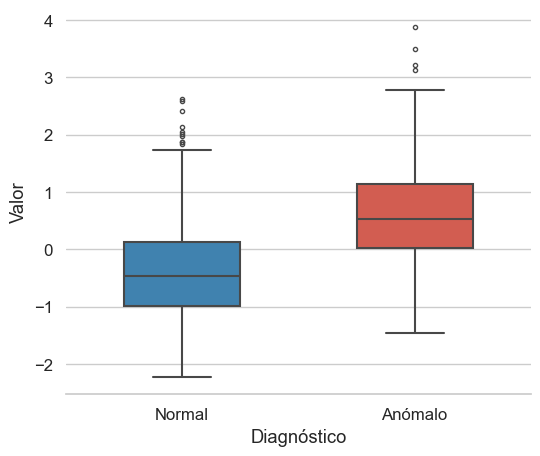

Boxplot de atributo: perimeter_worst


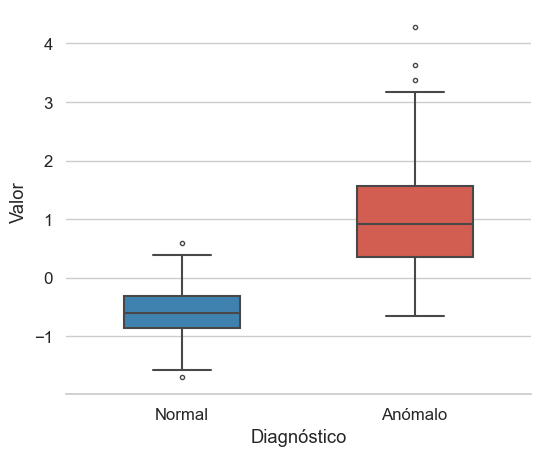

Boxplot de atributo: area_worst


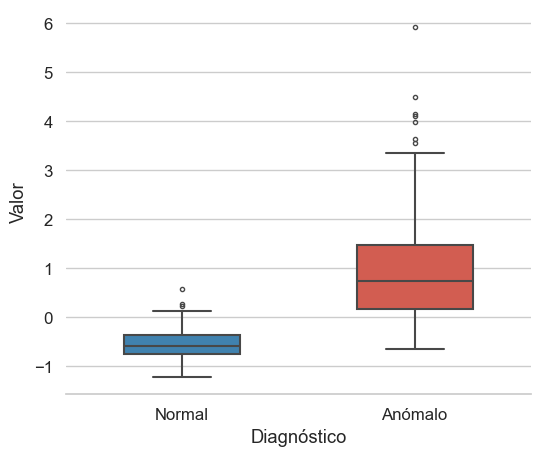

Boxplot de atributo: smoothness_worst


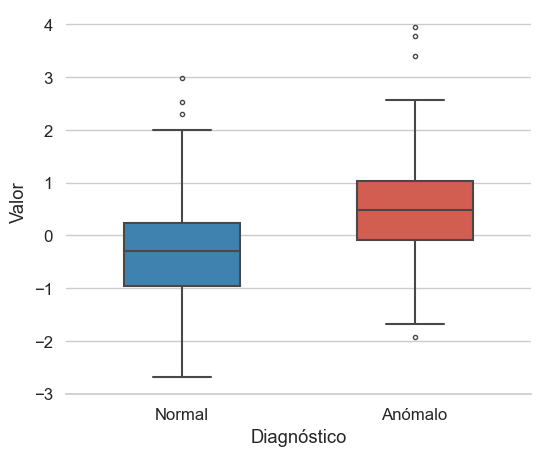

Boxplot de atributo: compactness_worst


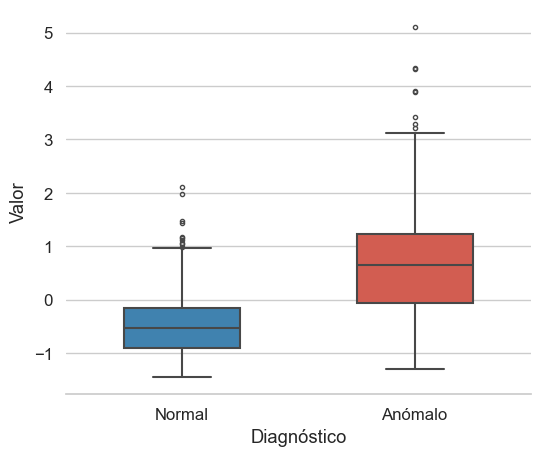

Boxplot de atributo: concavity_worst


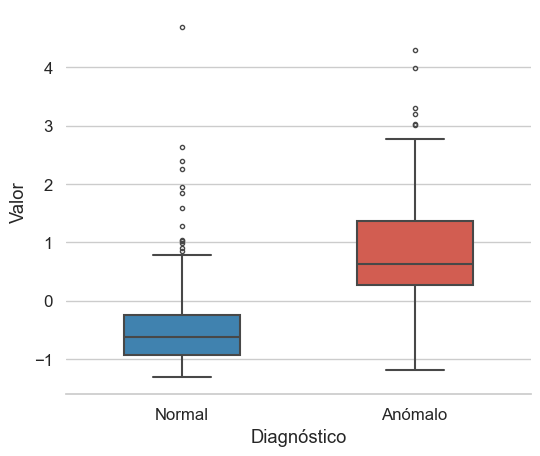

Boxplot de atributo: concave points_worst


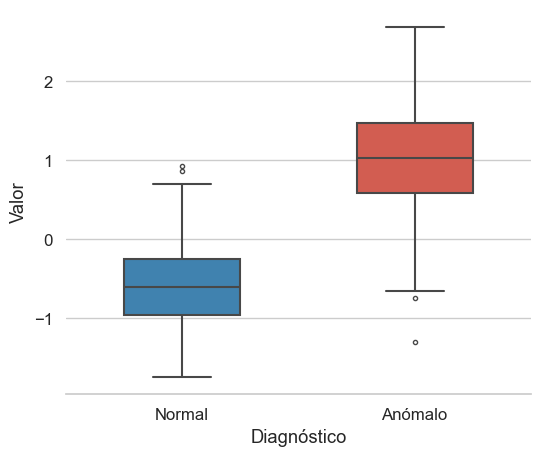

Boxplot de atributo: symmetry_worst


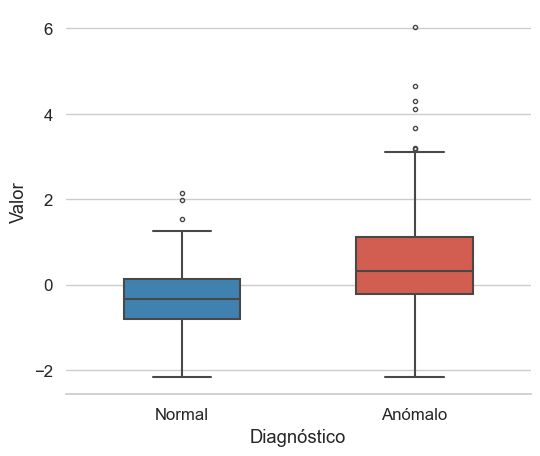

Boxplot de atributo: fractal_dimension_worst


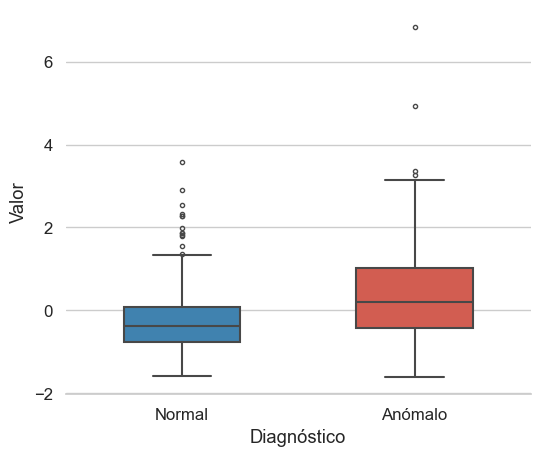

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df.copy()
plot_df['diagnosis'] = plot_df['diagnosis'].map({0: 'Normal', 1: 'Anómalo'})

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

cols = plot_df.drop(columns=['diagnosis']).columns
colores = {'Normal': '#2E86C1', 'Anómalo': '#E74C3C'}
orden_deseado = ['Normal', 'Anómalo']

for col in cols:
    print(f"Boxplot de atributo: {col}")
    plt.figure(figsize=(6, 5)) 
    sns.boxplot(data=plot_df,  x='diagnosis',  y=col,  hue='diagnosis',  palette=colores,  order=orden_deseado,
                legend=False, linewidth=1.5, width=0.5, fliersize=3)
    plt.ylabel('Valor')
    plt.xlabel('Diagnóstico')
    #plt.title(col, fontweight='bold', pad=10)
    sns.despine(left=True, top=True)
    
    plt.show()

## Distribución de los datos

Nota: para la elección del ancho de los bins en los histogramas se utilizó la regla de -nombre-.



Distribución de atributo: radius_mean


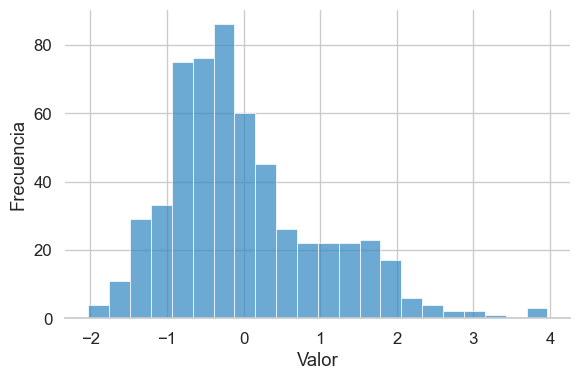

Distribución de atributo: texture_mean


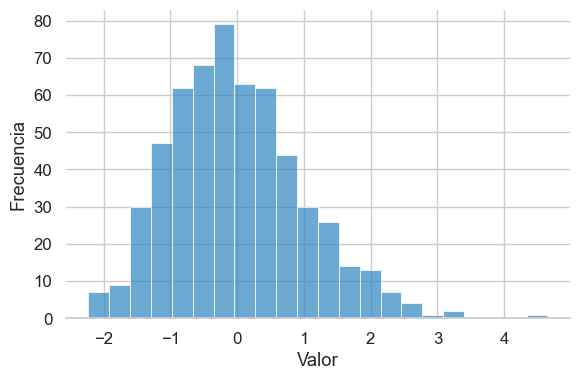

Distribución de atributo: perimeter_mean


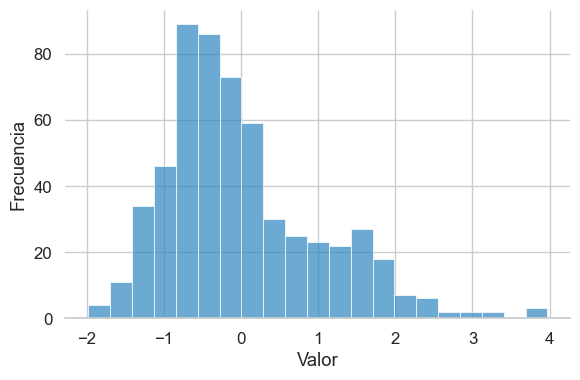

Distribución de atributo: area_mean


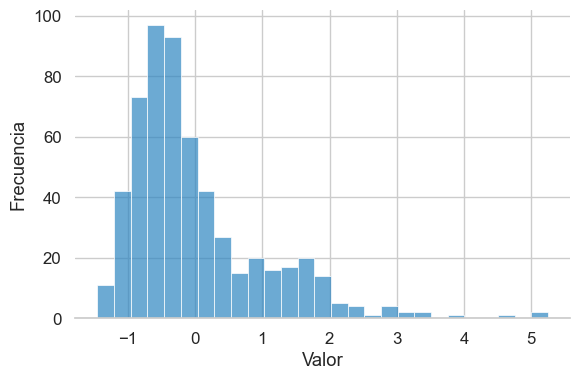

Distribución de atributo: smoothness_mean


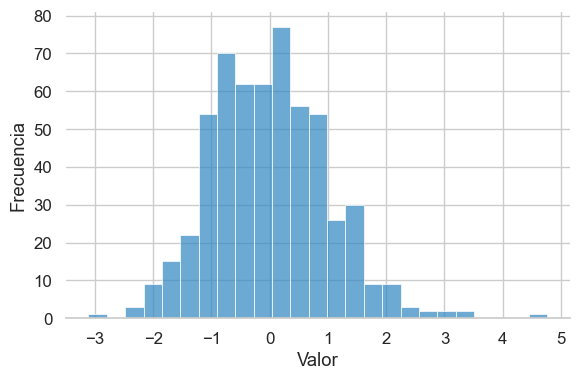

Distribución de atributo: compactness_mean


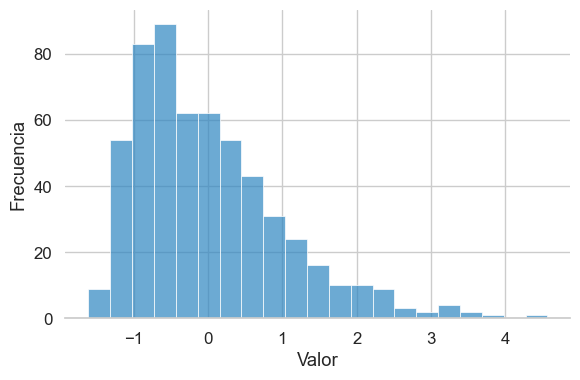

Distribución de atributo: concavity_mean


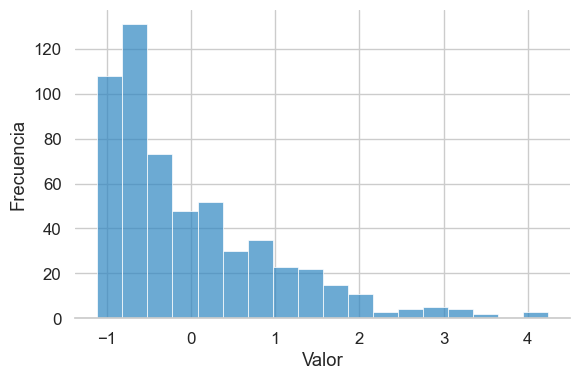

Distribución de atributo: concave points_mean


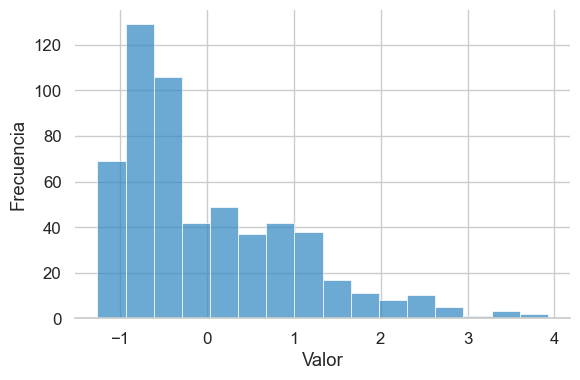

Distribución de atributo: symmetry_mean


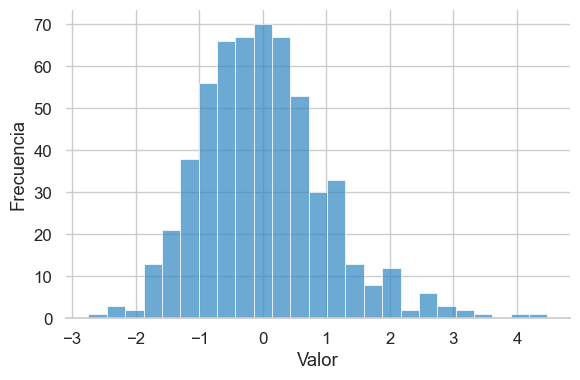

Distribución de atributo: fractal_dimension_mean


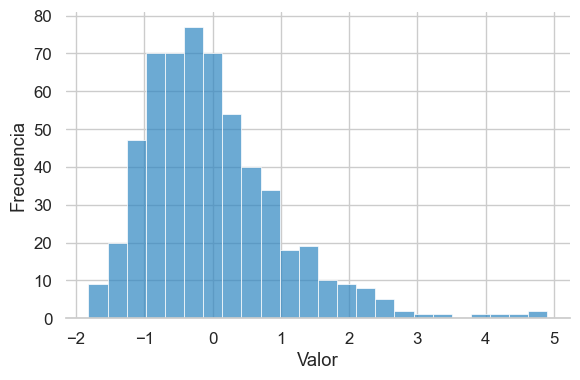

Distribución de atributo: radius_se


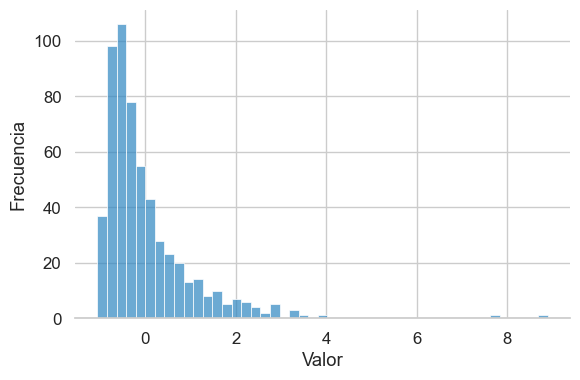

Distribución de atributo: texture_se


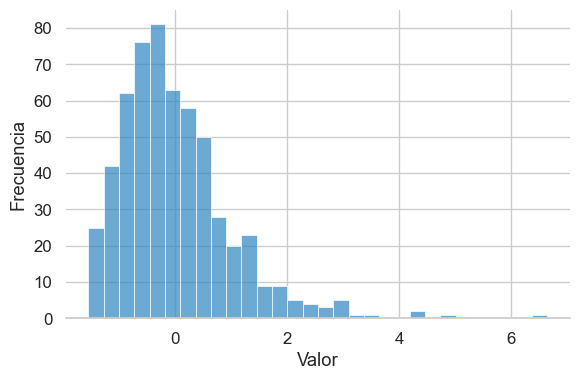

Distribución de atributo: perimeter_se


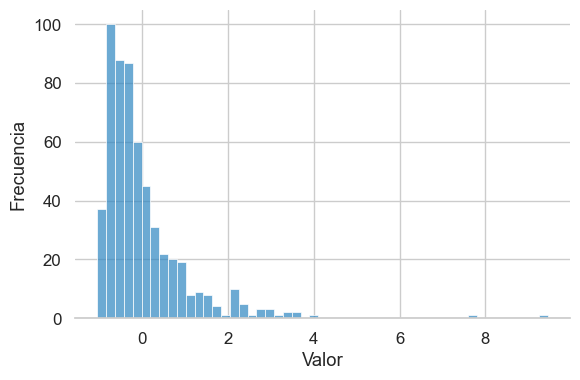

Distribución de atributo: area_se


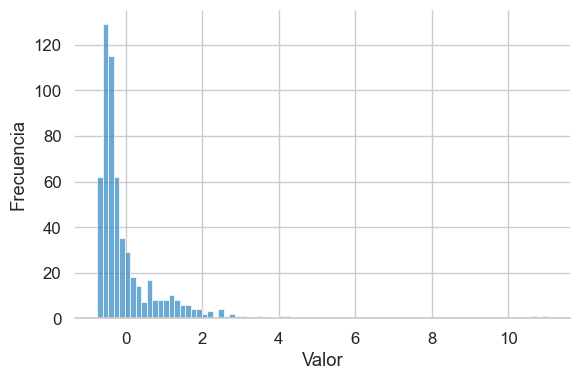

Distribución de atributo: smoothness_se


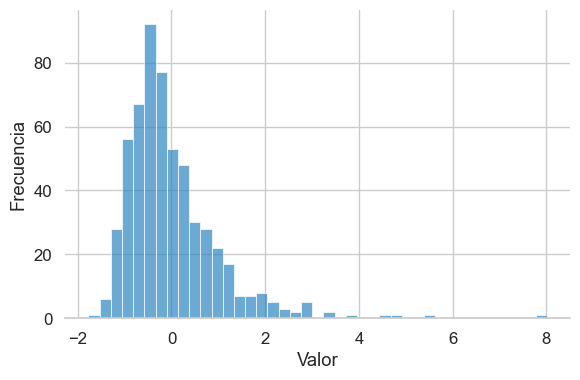

Distribución de atributo: compactness_se


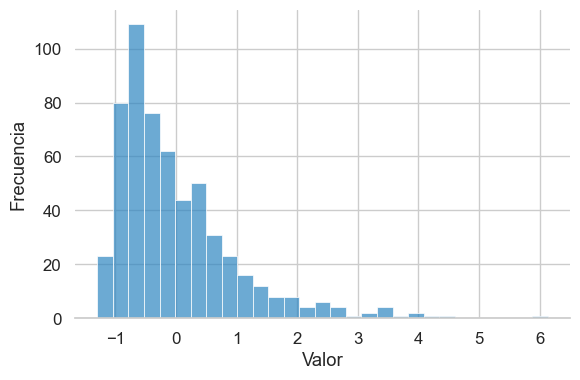

Distribución de atributo: concavity_se


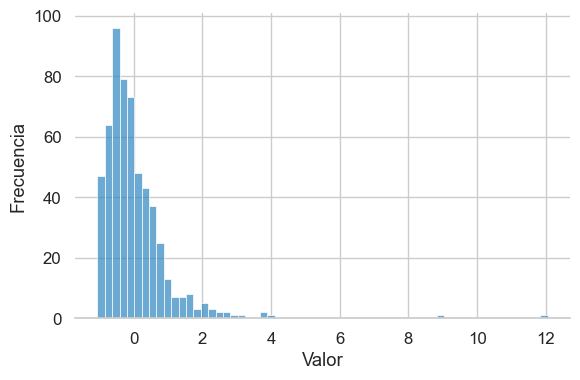

Distribución de atributo: concave points_se


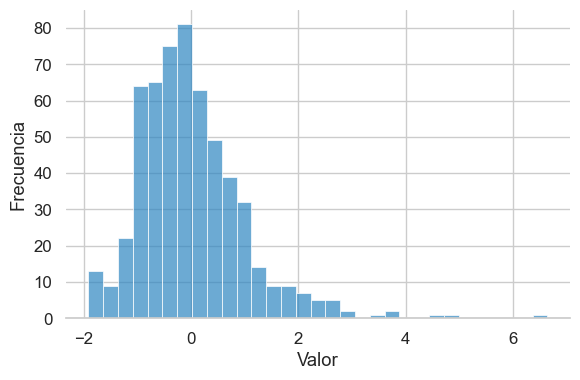

Distribución de atributo: symmetry_se


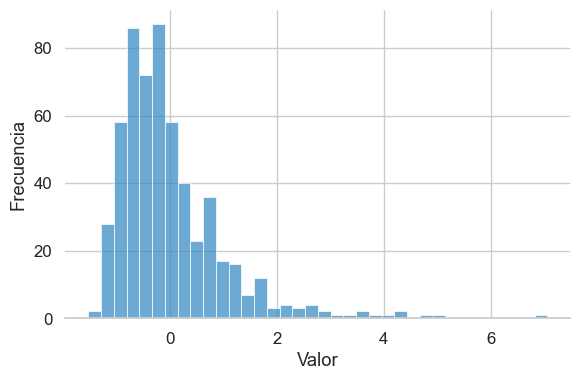

Distribución de atributo: fractal_dimension_se


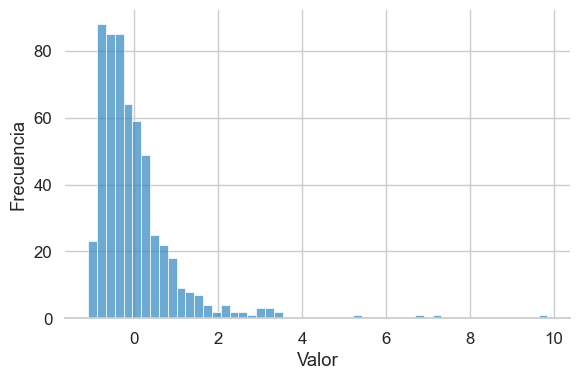

Distribución de atributo: radius_worst


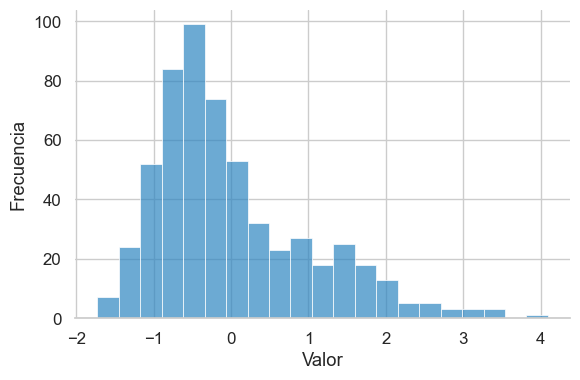

Distribución de atributo: texture_worst


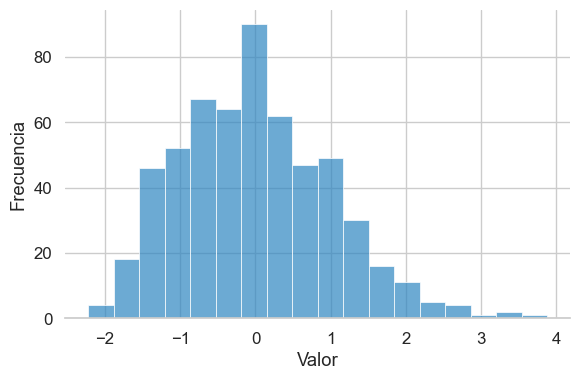

Distribución de atributo: perimeter_worst


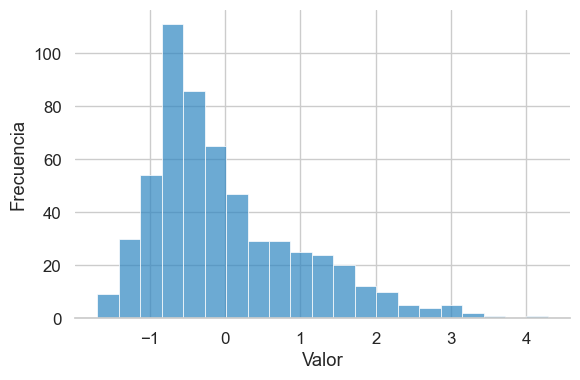

Distribución de atributo: area_worst


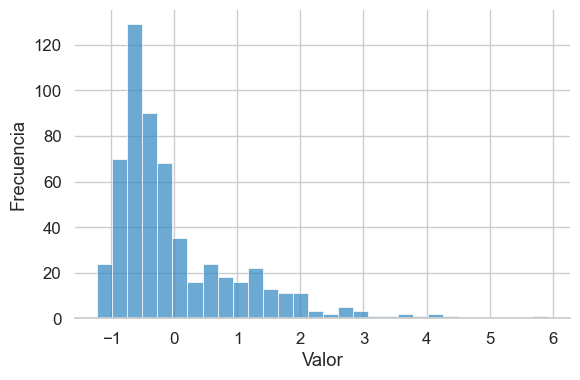

Distribución de atributo: smoothness_worst


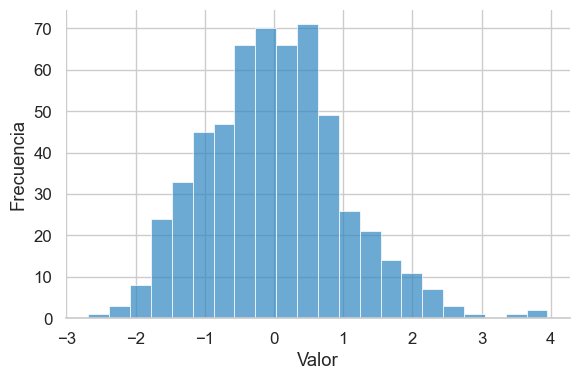

Distribución de atributo: compactness_worst


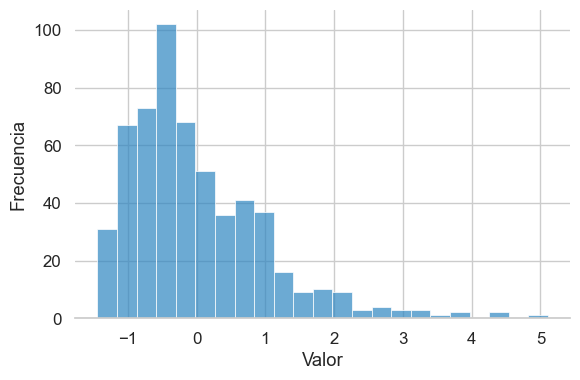

Distribución de atributo: concavity_worst


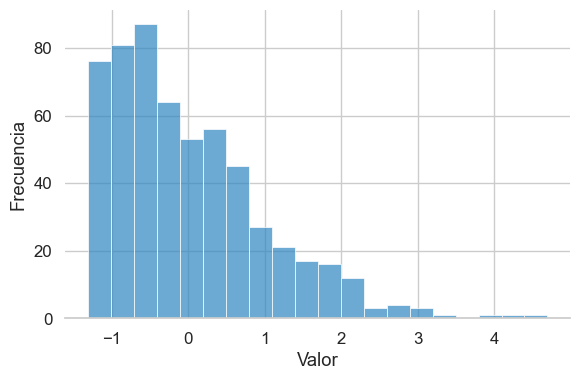

Distribución de atributo: concave points_worst


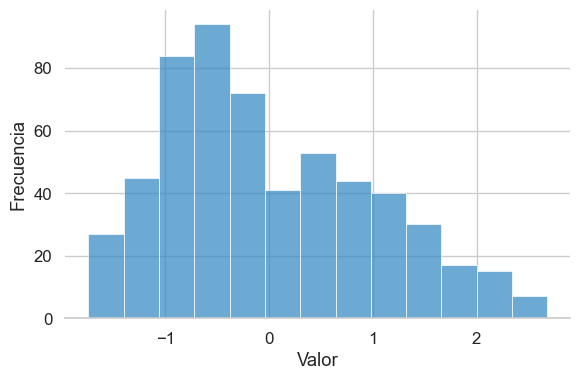

Distribución de atributo: symmetry_worst


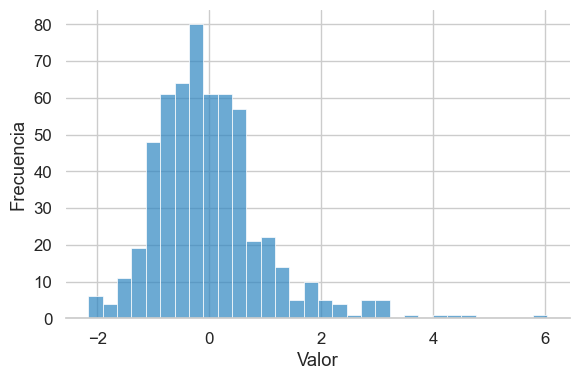

Distribución de atributo: fractal_dimension_worst


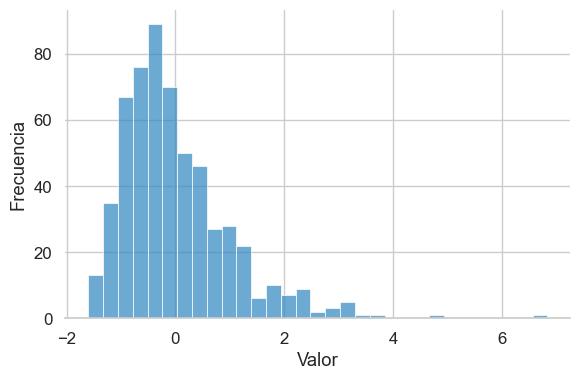

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df_num = df.drop(columns=["diagnosis"])

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

for col in df_num.columns:
    print(f"Distribución de atributo: {col}")
    plt.figure(figsize=(6, 4))
    sns.histplot(df_num[col], kde=False, color='#2E86C1', edgecolor='white', linewidth=0.5, alpha=0.7)
    #plt.title(col, fontweight='bold', pad=10)
    plt.ylabel('Frecuencia')
    plt.xlabel('Valor')
    sns.despine(left=True, top=True)
    plt.tight_layout()

    plt.show()

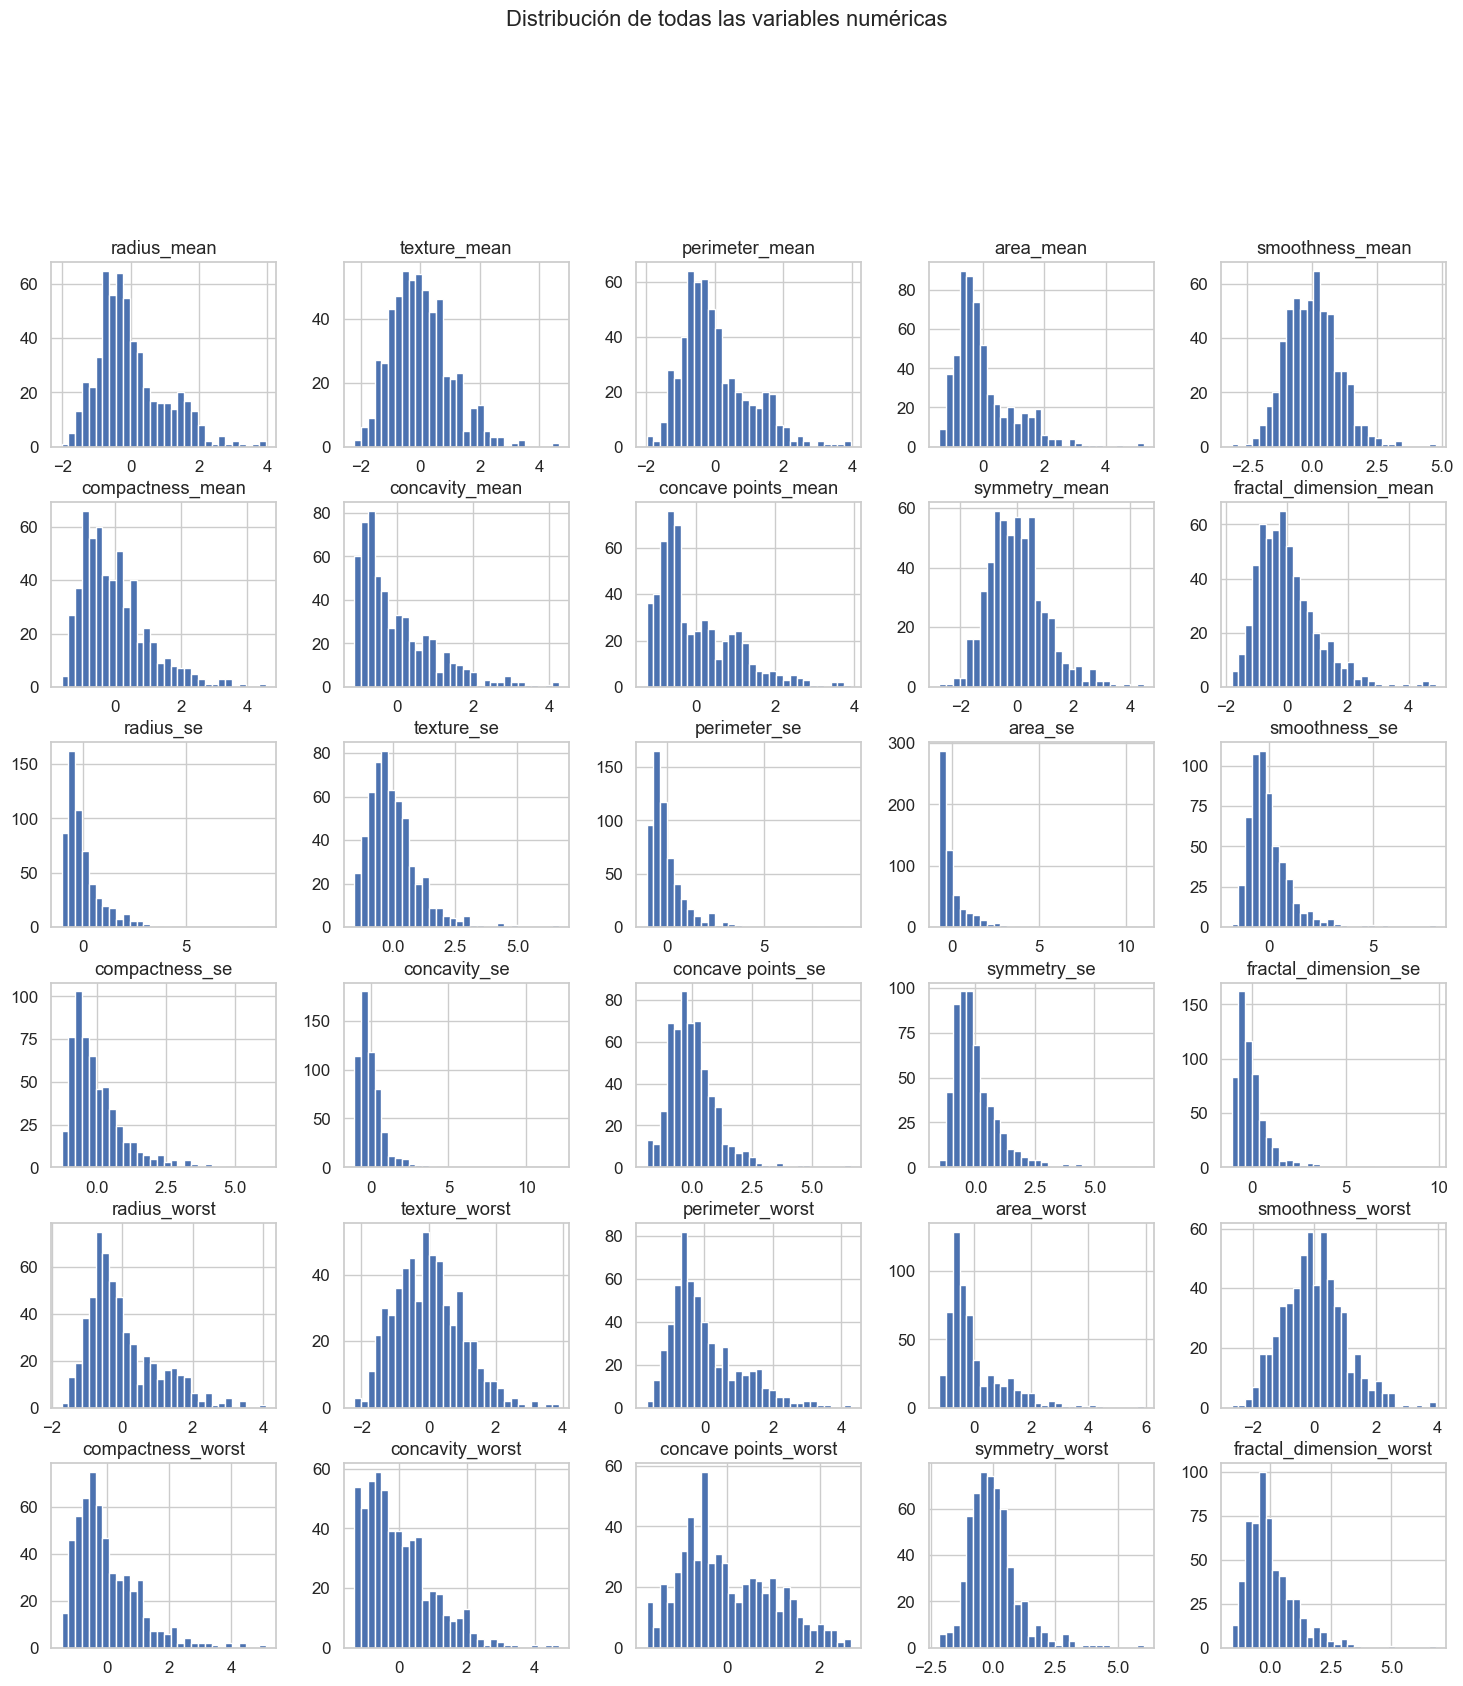

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df_num = df.drop(columns=["diagnosis"])

df_num.hist(figsize=(18, 18), bins=30)
plt.suptitle("Distribución de todas las variables numéricas", y=1.02)
plt.show()
